# WalkingDict — Retrieval & Generation Evaluation

Loads `data/eval/eval_results.jsonl` (produced by `scripts/run_eval.py`) and computes the numbers for report §6:

1. Hit@k, MRR — overall and per bucket (with 95% bootstrap CIs)
2. Per-layer coverage & precision
3. Spell-correction trace
4. Latency breakdown (p50/p95)
5. LLM-response rubric scoring
6. Subjective example traces

**Before running:**
```
conda run -n study python -m scripts.run_eval              # retrieval only
conda run -n study python -m scripts.run_eval --with-llm   # also capture responses
```

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_colwidth", 140)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = REPO / "data" / "eval" / "eval_results" / "eval_120_results.jsonl"
FIGS = REPO / "notebooks" / "figs" / "eval_120"
FIGS.mkdir(exist_ok=True, parents=True)

rows = [json.loads(l) for l in RESULTS.read_text().splitlines() if l.strip()]
df = pd.DataFrame(rows)
df["mrr"] = df["rank_expected"].apply(lambda r: 1.0 / r if r else 0.0)
df["total_ms"] = df["latencies_ms"].apply(lambda d: d.get("total"))
df["llm_ms"] = df["latencies_ms"].apply(lambda d: d.get("llm"))
print(df.shape)
df.head(3)

(120, 20)


,query,expected_word,expected_source,bucket,method,correction,exact_words,similar_words,all_ranked,low_confidence,rank_expected,hit_at_1,hit_at_3,hit_at_5,hit_at_10,latencies_ms,response,mrr,total_ms,llm_ms
0,book,book,wiktionary,exact_common,exact,None,[book],"[phrase book, kama scootra, the pink book, the fault in our stars, cujo]","[book, phrase book, kama scootra, the pink book, the fault in our stars, cujo]",False,1.0,True,True,True,True,"{'total': 1147.84, 'llm': 22012.06}","1. (noun, slang) A source of information or entertainment, but sometimes used ironically because it's not 'cool' to read a book in today...",1.0,1147.84,22012.06
1,free,free,wiktionary,exact_common,exact,None,[free],"[free 99, on the arm, for free, free people, uncle sugar's magic checkbook]","[free, free 99, on the arm, for free, free people, uncle sugar's magic checkbook]",False,1.0,True,True,True,True,"{'total': 55.73, 'llm': 18566.07}","1. (adjective) lacking financial cost; available without paying money.\n Example: ""Did you see the free samples they handed out at the...",1.0,55.73,18566.07
2,dictionary,dictionary,wiktionary,exact_common,exact,None,[dictionary],"[school dictionary, bilingual dictionary, learner's dictionary, mrd, etymological dictionary]","[dictionary, school dictionary, bilingual dictionary, learner's dictionary, mrd, etymological dictionary]",False,1.0,True,True,True,True,"{'total': 53.55, 'llm': 10318.13}","1. (noun) a book (or digital tool) that lists words in alphabetical order and gives their meanings, spellings, and how to use them.\nIma...",1.0,53.55,10318.13


## 1. Retrieval metrics (overall + per bucket) with bootstrap CIs

In [2]:
def bootstrap_ci(x: np.ndarray, n: int = 1000, alpha: float = 0.05, seed: int = 0) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    if len(x) == 0:
        return (np.nan, np.nan)
    means = rng.choice(x, size=(n, len(x)), replace=True).mean(axis=1)
    return (float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2)))

def summary(frame: pd.DataFrame) -> dict:
    out = {"n": len(frame)}
    for k in ["hit_at_1", "hit_at_3", "hit_at_5", "hit_at_10"]:
        vals = frame[k].astype(float).to_numpy()
        lo, hi = bootstrap_ci(vals)
        out[k] = f"{vals.mean():.2f} [{lo:.2f}, {hi:.2f}]"
    mrr_vals = frame["mrr"].to_numpy()
    lo, hi = bootstrap_ci(mrr_vals)
    out["mrr"] = f"{mrr_vals.mean():.2f} [{lo:.2f}, {hi:.2f}]"
    return out

overall = pd.DataFrame([{"bucket": "OVERALL", **summary(df)}])
per_bucket = pd.DataFrame([{"bucket": b, **summary(g)} for b, g in df.groupby("bucket")])
table = pd.concat([overall, per_bucket], ignore_index=True)
table

,bucket,n,hit_at_1,hit_at_3,hit_at_5,hit_at_10,mrr
0,OVERALL,120,"0.68 [0.60, 0.77]","0.73 [0.66, 0.82]","0.77 [0.69, 0.84]","0.77 [0.69, 0.84]","nan [nan, nan]"
1,exact_common,24,"1.00 [1.00, 1.00]","1.00 [1.00, 1.00]","1.00 [1.00, 1.00]","1.00 [1.00, 1.00]","1.00 [1.00, 1.00]"
2,idiom,24,"0.62 [0.46, 0.79]","0.62 [0.46, 0.79]","0.62 [0.46, 0.79]","0.62 [0.46, 0.79]","nan [nan, nan]"
3,paraphrase,24,"0.25 [0.08, 0.42]","0.42 [0.25, 0.62]","0.54 [0.33, 0.75]","0.54 [0.33, 0.75]","nan [nan, nan]"
4,slang,24,"0.96 [0.88, 1.00]","0.96 [0.88, 1.00]","0.96 [0.88, 1.00]","0.96 [0.88, 1.00]","nan [nan, nan]"
5,typo,24,"0.58 [0.42, 0.75]","0.67 [0.50, 0.83]","0.71 [0.54, 0.88]","0.71 [0.54, 0.88]","nan [nan, nan]"


## 2. Per-layer coverage and precision

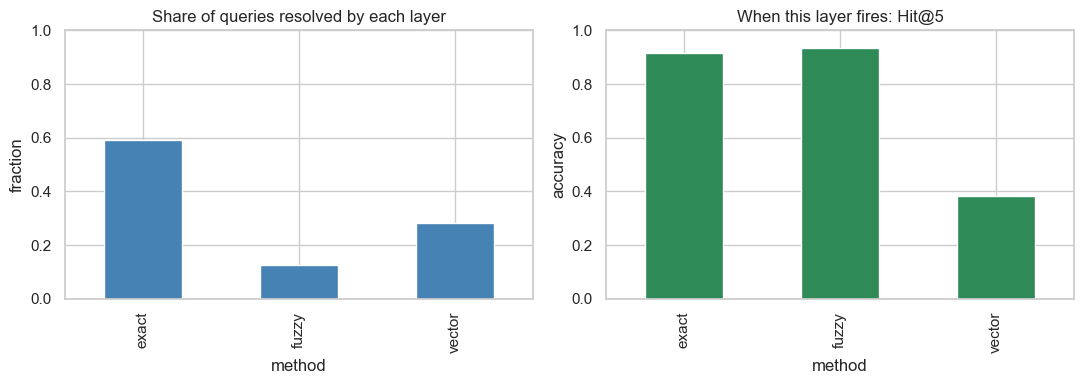

,coverage,precision_at5,mrr
method,,,
exact,0.592,0.915,0.970
fuzzy,0.125,0.933,1.000
vector,0.283,0.382,0.669


In [3]:
# Coverage = fraction of queries resolved by each method
# Precision = when this method fires, how often was the expected word in top-5?
method_stats = (df.groupby("method")
                  .agg(coverage=("method", "size"),
                       precision_at5=("hit_at_5", "mean"),
                       mrr=("mrr", "mean"))
                  .assign(coverage=lambda d: d["coverage"] / len(df))
                  .round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
method_stats["coverage"].plot.bar(ax=ax[0], color="steelblue")
ax[0].set(title="Share of queries resolved by each layer", ylabel="fraction", ylim=(0, 1))
method_stats["precision_at5"].plot.bar(ax=ax[1], color="seagreen")
ax[1].set(title="When this layer fires: Hit@5", ylabel="accuracy", ylim=(0, 1))
plt.tight_layout(); plt.savefig(FIGS / "layer_breakdown.png", dpi=150); plt.show()
method_stats

## 3. Spell correction trace

In [4]:
typos = df[df["bucket"] == "typo"].copy()
typos["corrected_to"] = typos["correction"].apply(lambda c: c and c.get("corrected"))
typos["correction_right"] = typos.apply(
    lambda r: pd.notna(r["expected_word"]) and 
              str(r["corrected_to"] or "").lower() == str(r["expected_word"]).lower(), axis=1)

print(f"Typo queries: {len(typos)}")
print(f"SymSpell fired: {typos['corrected_to'].notna().sum()}")
print(f"Correction matched expected: {typos['correction_right'].sum()} / {len(typos)}")
typos[["query", "expected_word", "corrected_to", "method", "hit_at_5", "correction_right"]]

Typo queries: 24
SymSpell fired: 16
Correction matched expected: 15 / 24


,query,expected_word,corrected_to,method,hit_at_5,correction_right
24,recieve,receive,NaN,exact,True,False
25,dictionery,dictionary,dictionary,fuzzy,True,True
26,gosting,ghosting,hosting,vector,False,False
27,beutiful,beautiful,NaN,exact,False,False
28,nesesary,necessary,necessary,fuzzy,True,True
29,occured,occurred,occurred,vector,False,True
30,seperate,separate,NaN,exact,True,False
31,definately,definitely,NaN,exact,False,False
32,accomodate,accommodate,accommodate,fuzzy,True,True
33,tommorow,tomorrow,NaN,exact,False,False


## 4. Latency breakdown

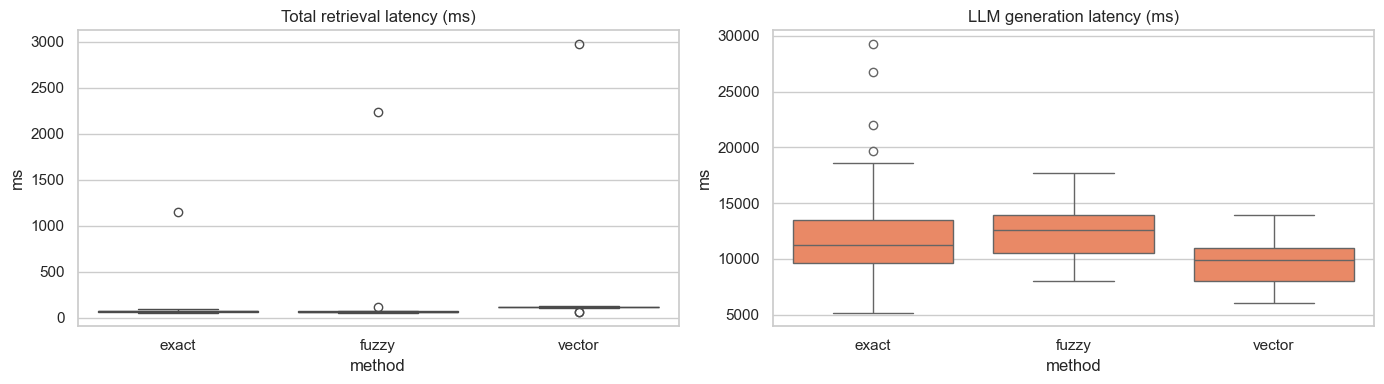

,p50,p95,mean,n
retrieval_total_ms,72.4,122.2,131.6,120.0
llm_ms (if --with-llm),10817.0,17746.2,11433.7,120.0


In [5]:
def pcts(s: pd.Series) -> dict:
    s = s.dropna()
    if s.empty:
        return {"p50": np.nan, "p95": np.nan, "mean": np.nan, "n": 0}
    return {"p50": s.quantile(0.5), "p95": s.quantile(0.95), "mean": s.mean(), "n": len(s)}

lat = pd.DataFrame({
    "retrieval_total_ms": pcts(df["total_ms"]),
    "llm_ms (if --with-llm)": pcts(df["llm_ms"]),
}).T.round(1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: total_ms only
sns.boxplot(data=df.melt(id_vars="method", value_vars=["total_ms"],
                         var_name="component", value_name="ms").dropna(),
            x="method", y="ms", ax=ax[0], color="steelblue")
ax[0].set_title("Total retrieval latency (ms)")
ax[0].set_ylabel("ms")

# Plot 2: llm_ms only
sns.boxplot(data=df.melt(id_vars="method", value_vars=["llm_ms"],
                         var_name="component", value_name="ms").dropna(),
            x="method", y="ms", ax=ax[1], color="coral")
ax[1].set_title("LLM generation latency (ms)")
ax[1].set_ylabel("ms")

plt.tight_layout()
plt.savefig(FIGS / "latency.png", dpi=150)
plt.show()
lat

## 6. Subjective example traces

Drop these straight into the report. Pick one per bucket:

In [6]:
for b in df["bucket"].unique():
    sub = df[df["bucket"] == b]
    pick = sub[sub["hit_at_5"]].head(1)
    if pick.empty:
        pick = sub.head(1)
    r = pick.iloc[0]
    print("=" * 70)
    print(f"BUCKET: {b}")
    print(f"  query         : {r['query']}")
    print(f"  expected_word : {r['expected_word']}")
    print(f"  method        : {r['method']}  (correction: {r.get('correction')})")
    print(f"  top-5 ranked  : {r['all_ranked'][:5]}")
    print(f"  rank(expected): {r['rank_expected']}")
    if "response" in r and isinstance(r["response"], str):
        print("  response (first 300 chars):")
        print("    " + r["response"][:300].replace("\n", "\n    "))

BUCKET: exact_common
  query         : book
  expected_word : book
  method        : exact  (correction: None)
  top-5 ranked  : ['book', 'phrase book', 'kama scootra', 'the pink book', 'the fault in our stars']
  rank(expected): 1.0
  response (first 300 chars):
    1. (noun, slang) A source of information or entertainment, but sometimes used ironically because it's not 'cool' to read a book in today's fast-paced world.
       Example: "My friends think I'm weird for carrying a book to the park, but I just want to escape into a good story."
    2. (noun) A physical obj
BUCKET: typo
  query         : recieve
  expected_word : receive
  method        : exact  (correction: None)
  top-5 ranked  : ['recieve', 'receive', 'receiver', 'begift', 'radio receiver']
  rank(expected): 2.0
  response (first 300 chars):
    You've stumbled upon a classic trap that catches many learners, but the story behind this word is actually a funny one about human nature.
    
    1. (verb) (slang) This is not

## 7. Honest limitations (fill in for §6.confidence)

- Gold set size is small (N ≈ 30–100) → wide CIs; report them.
- Gold set is self-authored → possible construction bias.
- Slang/idiom buckets depend on sources that may be empty in your current corpus — read those buckets cautiously.
- LLM-as-judge correlates imperfectly with humans — if both scored, report Cohen's κ on the shared subset.
- Latency measured on local hardware with warm caches; first-call cold-start excluded.